# 06 · Modelo Late Fusion

**Objetivo:** Entrenar dos modelos independientes (uno para imágenes, otro para tabular) y combinar sus predicciones mediante promedio ponderado.

**Datos de entrada:** `../data/raw/hnmist_28_28_RGB.csv`, `../data/raw/HAM10000_metadata.csv`

**Resultado esperado:** Modelos guardados en `../models/late_fusion_image_model.h5` y `../models/late_fusion_tabular_model.h5` con ~75% de accuracy combinado.

**Por qué Late Fusion es inferior a Early Fusion:** cada rama aprende de forma aislada, sin poder capturar las interacciones entre imagen y metadatos. La fusión en predicciones es un promedio de opiniones independientes, no un aprendizaje conjunto.

## Carga de datos, preprocesado y entrenamiento

**Ponderación de la fusión:** `pred_final = 0.6 * pred_imagen + 0.4 * pred_tabular`

Se da más peso a la rama de imagen porque históricamente las imágenes dermatoscópicas son la fuente primaria de diagnóstico en dermatología.

Columnas del dataset: Index(['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004',
       'pixel0005', 'pixel0006', 'pixel0007', 'pixel0008', 'pixel0009'],
      dtype='object')


c:\Users\rammu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,055 (54.90 KB)

 Trainable params: 13,671 (53.40 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6335 - loss: 2.0850 - val_accuracy: 0.6781 - val_loss: 1.8849
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6809 - loss: 1.6058 - val_accuracy: 0.6906 - val_loss: 1.4266
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6862 - loss: 1.3906 - val_accuracy: 0.6943 - val_loss: 1.2252
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6842 - loss: 1.2476 - val_accuracy: 0.6943 - val_loss: 1.1191
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6889 - loss: 1.1637 - val_accuracy: 0.7012 - val_loss: 1.0478
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6861 - loss: 1.1032 - val_accuracy: 0.6968 - val_loss: 1.0218
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6926 - loss: 1.0627 - val_accuracy: 0.7018 - val_loss: 0.9885
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6956 - loss: 1.0349 - val_accu

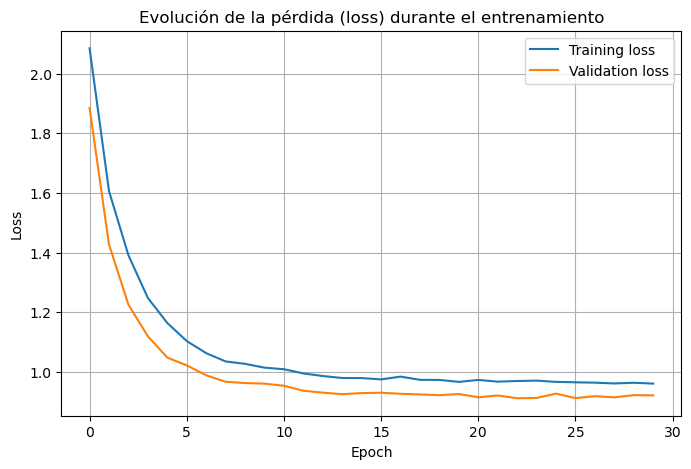

Epoch 1/50


c:\Users\rammu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\rammu\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6619 - loss: 1.0215 - val_accuracy: 0.1067 - val_loss: 2.4744
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6992 - loss: 0.8235 - val_accuracy: 0.1074 - val_loss: 2.0967
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7228 - loss: 0.7677 - val_accuracy: 0.3976 - val_loss: 1.7445
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7273 - loss: 0.7400 - val_accuracy: 0.6679 - val_loss: 1.3893
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7326 - loss: 0.7279 - val_accuracy: 0.5843 - val_loss: 1.0747
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7424 - loss: 0.7040 - val_accuracy: 0.6998 - val_loss: 1.0544
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7502 - loss: 0.6846 - val_accuracy: 0.7322 - val_loss: 0.7432
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7417 - loss: 0.6869 - val_accuracy: 0.714

🔹 Accuracy Late Fusion: 0.7439


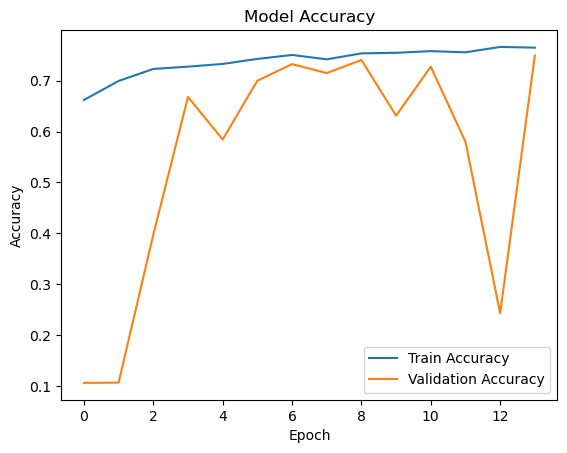

In [39]:
#Por último, vamos a hacer un modelo Late-fusion. En este tipo de modelos, se fusionan datos de distintas categorías 
#Al FINAL del proceso, 
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Concatenate, BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#Cargamos CSV 
path = r"../data/raw/hnmist_28_28_RGB.csv"
df = pd.read_csv(path)
print("Columnas del dataset:", df.columns[:10])  # para inspeccionar
# Cargamos metadata
metadata = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")

# Separamos etiquetas desde metadata (por posición, mismo orden que df)
y = metadata['dx'].values[:len(df)]

# codificamos las labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
num_classes = y_onehot.shape[1]

# Seleccionamos algunas variables numéricas/categóricas (por posición)
tabular_data = metadata[['age', 'sex', 'localization']][:len(df)]

# One-hot encoding para variables categóricas
tabular_data = pd.get_dummies(tabular_data, columns=['sex', 'localization'], drop_first=True)

# Normalización
tabular_data['age'] = tabular_data['age'] / tabular_data['age'].max()

tabular_features = tabular_data.values

# Dividir en train/test
X_img = df.values.astype(np.float32)  # convierte a float32
X_img = X_img.reshape(-1, 28, 28, 3)
X_img /= 255.0 
X_tab = tabular_features.astype(np.float32)
y_train_test = y_onehot

X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_img, X_tab, y_train_test, test_size=0.2, random_state=42, stratify=y_encoded
)
#En este punto, hemos hecho un pequeño arreglo que nos ayuda a 
X_tab_train = np.where(np.isinf(X_tab_train), np.nan, X_tab_train)

from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
X_tab_train = imp.fit_transform(X_tab_train)
X_tab_test = imp.transform(X_tab_test)

#Modelo tabular
input_tab = Input(shape=(X_tab_train.shape[1],))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_tab = Sequential([
    Dense(128, activation='relu', input_shape=(X_tab_train.shape[1],),
          kernel_regularizer='l2'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])
        # Compilar 
model_tab.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model_tab.summary()
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')
        # Entrenamiento
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True
)

history_tab = model_tab.fit(
    X_tab_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

#Evaluación 
import matplotlib.pyplot as plt

# Gráfica de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history_tab.history['loss'], label='Training loss')
plt.plot(history_tab.history['val_loss'], label='Validation loss')
plt.title('Evolución de la pérdida (loss) durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Modelo de imágenes
input_shape = (28, 28, 3)
num_classes = y_train.shape[1]

model_img = Sequential()
model_img.add(Conv2D(32, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model_img.add(BatchNormalization())
model_img.add(MaxPooling2D(pool_size=(2,2)))
model_img.add(Conv2D(64, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model_img.add(BatchNormalization())
model_img.add(MaxPooling2D(pool_size=(2,2)))
model_img.add(Conv2D(128, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model_img.add(BatchNormalization())
model_img.add(MaxPooling2D(pool_size=(2,2)))
model_img.add(Conv2D(256, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model_img.add(BatchNormalization())
model_img.add(MaxPooling2D(pool_size=(2,2)))
model_img.add(GlobalAveragePooling2D())
model_img.add(Dense(256, activation='relu'))
model_img.add(Dropout(0.5))
model_img.add(Dense(num_classes, activation='softmax'))

        # Compilar 
model_img.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow(X_img_train, y_train, batch_size=64, subset='training')
val_gen = datagen.flow(X_img_train, y_train, batch_size=64, subset='validation')

history_img = model_img.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop]
)
#Evaluación del modelo 

#obtenemos las predicciones de ambos modelos 
pred_img = model_img.predict(X_img_test)
pred_tab = model_tab.predict(X_tab_test)

import numpy as np

# Fusión ponderada por promedio
pred_fusion = (0.6*pred_img + 0.4*pred_tab) 

#evaluamos el modelo combinado
from sklearn.metrics import accuracy_score
import numpy as np

y_pred_classes = np.argmax(pred_fusion, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
print(f"🔹 Accuracy Late Fusion: {acc:.4f}")

# guardamos el modelo late fusion
model_img.save('../models/late_fusion_image_model.h5')
model_tab.save('../models/late_fusion_tabular_model.h5')
# Graficamos resultados del modelo de imágenes

import matplotlib.pyplot as plt

plt.plot(history_img.history['accuracy'], label='Train Accuracy')
plt.plot(history_img.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Evaluación detallada por clase

El accuracy global no es suficiente en diagnóstico médico. Aquí vemos cuánto acierta el modelo en **cada tipo de lesión** por separado, y lo comparamos con el **baseline ZeroR** (lo que conseguiría un modelo que predice siempre la clase más frecuente, sin aprender nada).

In [ ]:
from sklearn.metrics import classification_report
from collections import Counter

# Baseline ZeroR
most_common = Counter(y_true).most_common(1)[0][1]
baseline = most_common / len(y_true)
print(f'Baseline ZeroR (predecir siempre la clase más frecuente): {baseline:.2%}')
print(f'Accuracy Late Fusion: {acc:.2%}')
print(f'Mejora sobre baseline: {acc - baseline:+.2%}')

print('
Resultados por clase diagnóstica:')
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

# Modelo Late fusion: Conclusiones
En este modelo hemos alcanzado un valor de 0.75 aprox. el cual no es malo, pero es peor que en nuestro modelo Early fusion. 
Vemos que esto sucede porque, al procesar las dos modalidades de forma independiente hasta el final, la red no puede aprender interacciones profundas entre modalidades (es decir, yo he configurado que el peso de la parte tabular sea 0.4, y el peso de la parte de imágenes sea 0.6, pero no es una manera muy compleja de hacerlo)
Además, el aprendizaje para clasificar ambas modalidades no se hace de manera conjunta. 
Este tipo de red se utiliza en casos donde se busca la modularidad y la robustez, dado que al no tener interacciones tan complejas entre las dimensiones, es fácil sustituir una variable por otra
